# Master MIND - IDLE

# Descente de gradient et prise en main de PyTorch

------------------------------------------------------------------------

**Remarque:** Si vous arrivez ici sans avoir lu les instructions
d’installation sur la page du cours, ça ne va pas marcher. Goto
<https://schwander.isir.upmc.fr/enseignement/m1mind_idle/> dans ce cas.

# Exercice 1 - *Petits* *exemples* *PyTorch*

In [18]:
import torch
import matplotlib.pyplot as plt
from torchviz import make_dot

## Question 1 - *Tenseurs* *avec* *et* *sans* *gradient*

In [19]:
a = 5.0
b = torch.tensor(a) # requires_grad= False by default
# nice to avoid building computational graph for constants and other issues
x  = torch.tensor(a, requires_grad=True)

-   Quelle est la différence entre les variables `a` et `b` et `x` ?

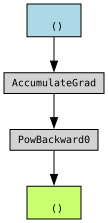

In [20]:
y = x**2
make_dot(y)

-   Dessiner le graphe de calcul associé à `y`. Que constate-t-on en
    affichant la valeur de la variable ?

## Question 2 - *Calcul* *des* *gradients*

La passe backward est effectuée avec l’opération suivante:

In [21]:
y.backward()

On obtient le gradient par rapport à une variable de la façon suivante:

In [22]:
dy_dx = x.grad
dy_dx

tensor(10.)

## Question 3 - *Graphe* *plus* *complexe*

-   Dessiner le graphe de calcul associé aux instructions suivantes:

tensor(13., grad_fn=<AddBackward0>)


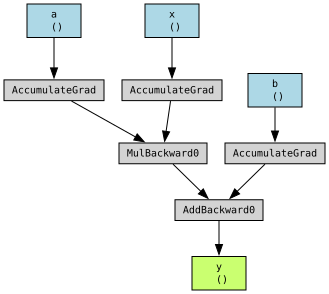

In [23]:
x = torch.tensor(5., requires_grad=True)
a = torch.tensor(2., requires_grad=True)
b = torch.tensor(3., requires_grad=True)
k = torch.tensor(2., requires_grad=True)

y = a * x + b
z = x**k
vars = {"x":x, "a":a, "b": b, "k":k, "y" : y, "z" : z}
print(y)
make_dot(y, params=vars)

In [24]:
y.backward()
print(f"dy/dx = {x.grad}")
print(f"dy/da = {a.grad}")
print(f"dy/db = {b.grad}")
print(f"dy/dk = {k.grad}")

dy/dx = 2.0
dy/da = 5.0
dy/db = 1.0
dy/dk = None


-   Dériver `y` vérifier les valeurs des dérivées pour toutes les
    entrées du graphe.

-   Peut-on maintenant dériver `z` ? Expliquer ce qui se passe si on
    exécute le code suivant ?

In [25]:
z.backward()
x.grad # FAUX 12 instead of 10

tensor(12.)

The problem is that gradients are accumulating 12 = 2 + 10, we need to reinitialize the computational graph.

In [26]:
z = x**k
x.grad = None 
z.backward()
x.grad

tensor(10.)

**À RETENIR** On peut faire qu’une seule passe backward. Si on veut
calculer de nouveaux gradients, on doit réinitialiser le graphe de
calcul. Dans le contexte du deep learning, on dérive uniquement la loss
donc a priori ça n’est pas génant. Cependant, il faut faire attention
lors des itérations de la descente de gradient à bien réinitialiser les
valeurs des gradients.

# Exercice 2 - *Descente* *de* *gradient*

On va faire ici une implémentation manuelle de la descente de gradient.
L’objectif est de minimiser la fonction $f(w) = 0.25w^4 -
1.5w^3 - 1.25w^2 + 6*w$.

## Question 4 - *Implémentation*

-   Compléter la boucle d’optimisation suivante.

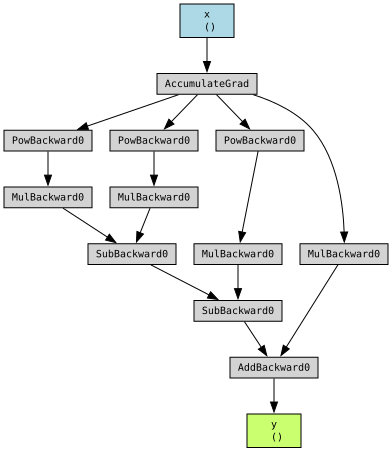

In [27]:
x = torch.tensor(5., requires_grad=True)
y = 0.25 * x**4 - 1.5 * x**3 - 1.25 * x**2 + 6*x
make_dot(y,{"x":x, "y":y})

In [28]:
lr = 0.1

x = torch.tensor(5., requires_grad=True)
plt.figure()

# X = 
for i in range(100):
    y = 0.25 * x**4 - 1.5 * x**3 - 1.25 * x**2 + 6*x

    y.backward()

    x = (x - lr * x.grad).detach()
    x.requires_grad = True

    print(x,y)
    # plt.plot(x.detach().numpy(), y.detach().numpy())

tensor(4.4000, requires_grad=True) tensor(-32.5000, grad_fn=<AddBackward0>)
tensor(5.0936, requires_grad=True) tensor(-31.8736, grad_fn=<AddBackward0>)
tensor(4.2269, requires_grad=True) tensor(-31.8151, grad_fn=<AddBackward0>)
tensor(5.1716, requires_grad=True) tensor(-30.4486, grad_fn=<AddBackward0>)
tensor(4.0684, requires_grad=True) tensor(-31.0481, grad_fn=<AddBackward0>)
tensor(5.1999, requires_grad=True) tensor(-28.7973, grad_fn=<AddBackward0>)
tensor(4.0075, requires_grad=True) tensor(-30.7230, grad_fn=<AddBackward0>)
tensor(5.2003, requires_grad=True) tensor(-28.0892, grad_fn=<AddBackward0>)
tensor(4.0065, requires_grad=True) tensor(-30.7176, grad_fn=<AddBackward0>)
tensor(5.2003, requires_grad=True) tensor(-28.0775, grad_fn=<AddBackward0>)
tensor(4.0066, requires_grad=True) tensor(-30.7181, grad_fn=<AddBackward0>)
tensor(5.2003, requires_grad=True) tensor(-28.0785, grad_fn=<AddBackward0>)
tensor(4.0066, requires_grad=True) tensor(-30.7181, grad_fn=<AddBackward0>)
tensor(5.200

<Figure size 640x480 with 0 Axes>

## Question 5 - *Expériences*

-   Constatez expérimentalement l’influence des hyperparamètres vus en
    TD:
    -   learning rate
    -   initialisation

On veillera pour chaque expérience à tracer l’évolution de la fonction
objectif et à l’analyser.

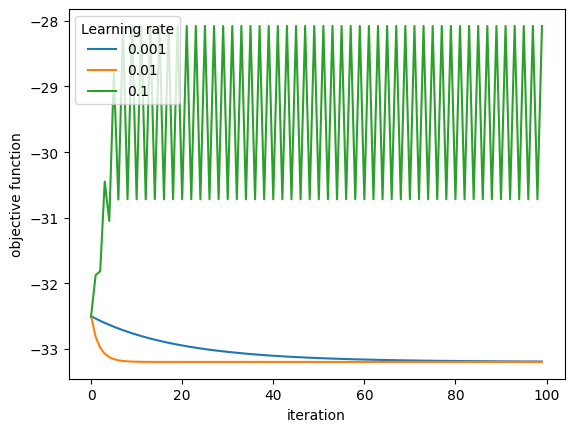

In [58]:
lrs = [1e-3, 1e-2, 1e-1]
n_iter = 100
plt.figure()

for lr in lrs:
    Y = []
    x = torch.tensor(5., requires_grad=True)
    for i in range(n_iter):
        y = 0.25 * x**4 - 1.5 * x**3 - 1.25 * x**2 + 6*x

        y.backward()

        with torch.no_grad():
            x -= lr * x.grad # NOTE: -= is in-place
        x.grad = None

        # NOTE: alternatively
        # x = (x - lr * x.grad).detach()
        # x.requires_grad = True
        
        Y.append(y.item())
    plt.plot(list(range(0, n_iter)), Y, label=lr)
plt.xlabel("iteration")
plt.ylabel("objective function")
plt.legend(title="Learning rate")

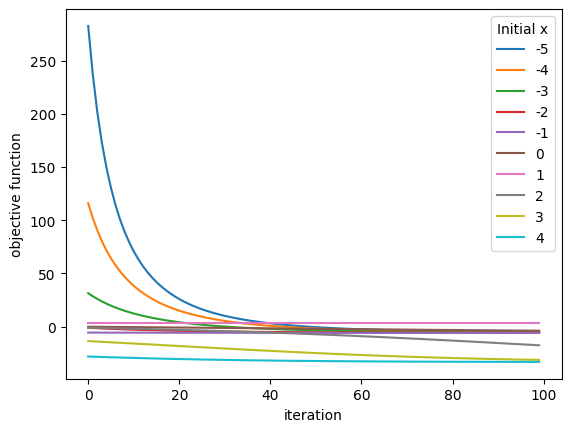

In [68]:
lr = 1e-3
n_iter = 100
plt.figure()

for x_init in range(-5, 5, 1):
    Y = []
    x = torch.tensor(float(x_init), requires_grad=True)
    for i in range(n_iter):
        y = 0.25 * x**4 - 1.5 * x**3 - 1.25 * x**2 + 6*x

        y.backward()
        with torch.no_grad():
            x -= lr * x.grad # NOTE: -= is in-place
        x.grad = None

        # x = (x - lr * x.grad).detach()
        # x.requires_grad = True

        Y.append(y.detach().numpy())
    plt.plot(list(range(0, n_iter)), Y, label=x_init)
plt.legend(title="Initial x")
plt.xlabel("iteration")
plt.ylabel("objective function")
plt.show()

-   Comment bien gérer le nombre d’itérations ?

Stop when objective function seems to converge.


# Exercice 3 - *Régression* *linaire*

## Question 6 - *Données* *toutes* *simples*

On va générer et afficher des données artificielles pour une tâche de
régression linéaire.

In [69]:
x = torch.arange(0, 10, 0.1, requires_grad=False)
y = 2 * x + 5 + torch.randn(100)
y

tensor([ 3.9301,  6.8919,  6.8784,  4.1470,  6.0417,  6.5157,  5.6071,  6.4232,
         6.5609,  7.4453,  7.5182,  5.5864,  8.8872,  7.6045,  7.0479,  7.7491,
         7.6855, 10.8567,  9.2387, 10.0714, 10.3126,  8.9563,  8.3365, 10.3029,
         9.7427,  9.0391, 11.5763, 10.4829,  9.2917, 12.1470, 12.1051,  9.8118,
        12.3261, 10.6774, 12.1652, 10.5210, 10.8332, 14.6508, 13.5886, 15.3425,
        12.5379, 14.2625, 13.7843, 11.9335, 13.8275, 13.4715, 12.7205, 14.2732,
        15.2394, 15.6025, 17.1469, 15.2927, 16.4382, 13.9285, 16.8808, 15.7619,
        16.3015, 14.8836, 14.6670, 16.6707, 17.6902, 17.6593, 16.5602, 16.3042,
        18.3801, 16.8535, 18.0287, 19.1206, 18.6547, 17.7524, 17.8457, 18.4886,
        19.4235, 18.6369, 22.4330, 21.8143, 19.6309, 20.6945, 21.0929, 20.7900,
        21.7856, 20.6502, 20.9117, 21.1829, 22.7639, 24.4436, 21.3483, 21.2241,
        22.6426, 20.9896, 24.1385, 24.2159, 23.0822, 24.1082, 22.2403, 24.5892,
        25.2280, 26.1848, 23.4365, 24.85

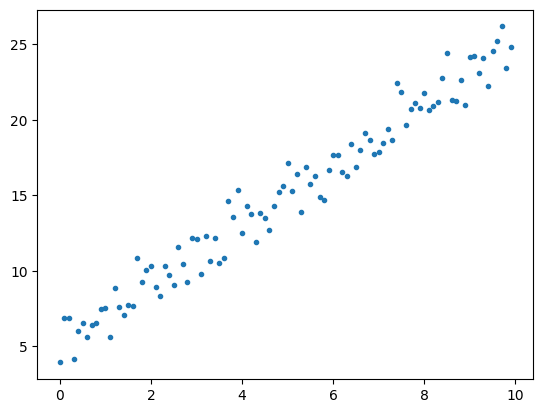

In [70]:
plt.plot(x.detach().numpy(), y.detach().numpy(), ".")
plt.show()

## Question 7 - *Numpy* *et* *Pytorch*

Expliquer le `.detach()` dans la cellule précédente.

Because we don't want matplotlib to interact with Autograd.

## Question 8 - *À* *la* *main*

Réalisez l’apprentissage en écrivant la boucle d’optimisation à la main.

tensor([1.9888, 5.1312], requires_grad=True)


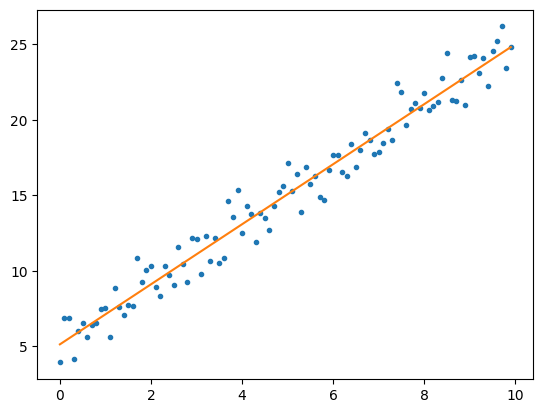

In [117]:
w = torch.tensor([0.,0.], requires_grad=True) 
lr = 0.01
n_iter = 1000
losses = []
for i in range(n_iter):
    y_hat = w[0]*x + w[1]
    mse = torch.mean((y_hat - y)**2)
    mse.backward()
    losses.append(mse.detach())
    with torch.no_grad():
        w -= lr*w.grad
    w.grad = None
print(w)
plt.plot(x.detach().numpy(), y.detach().numpy(), ".")
plt.plot(x.detach().numpy(),y_hat.detach().numpy())

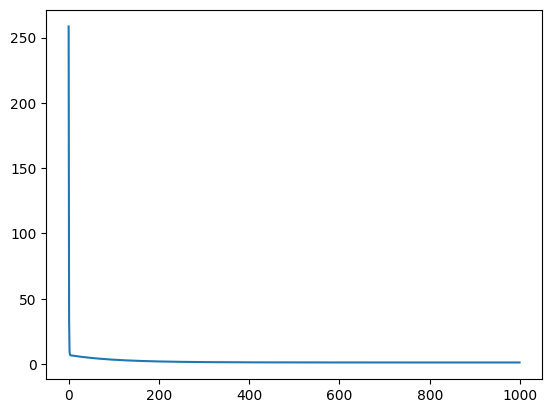

In [118]:
plt.plot(torch.arange(n_iter), losses)

Pour le moment on s’intéresse uniquement à l’aspect technique de Torch,
on ne fera donc pas d’évaluation expérimentale. Néanmoins il est capital
de vérifier que l’optimisation se passe bien en traçant l’évolution de
la loss.

## Question 9 - *La* *vraie* *version* *pytorch*

Voici la vraie implémentation d’un module de régression linéaire:

NB: torch can handle separate variables with computational graph, but it can handle blocks (Modules) as well.

In [121]:
class linearRegression(torch.nn.Module):
    def __init__(self, inputSize, outputSize):
        super(linearRegression, self).__init__()
        self.linear = torch.nn.Linear(inputSize, outputSize)

    def forward(self, x):
        out = self.linear(x)
        return out

In [133]:
model = linearRegression(1, 1)
criterion = torch.nn.MSELoss() 
optimizer = torch.optim.SGD(model.parameters(), lr=0.01) # called SGD, but here used as batch
losses = []
for epoch in range(n_iter):
    # clean old gradients
    optimizer.zero_grad()

    # forward pass
    outputs = model(x.reshape((-1, 1)))

    # compute loss
    loss = criterion(outputs, y.reshape((-1, 1)))
    # backward pass - compute gradient
    loss.backward()

    # update parameters
    optimizer.step()
    losses.append(loss.item())
    print(epoch, loss, model.linear.weight.data, model.linear.bias.data)

0 tensor(240.1738, grad_fn=<MseLossBackward0>) tensor([[1.7792]]) tensor([0.7386])
1 tensor(31.1427, grad_fn=<MseLossBackward0>) tensor([[2.3517]]) tensor([0.8474])
2 tensor(8.5771, grad_fn=<MseLossBackward0>) tensor([[2.5375]]) tensor([0.8973])
3 tensor(6.1046, grad_fn=<MseLossBackward0>) tensor([[2.5963]]) tensor([0.9278])
4 tensor(5.7977, grad_fn=<MseLossBackward0>) tensor([[2.6135]]) tensor([0.9519])
5 tensor(5.7245, grad_fn=<MseLossBackward0>) tensor([[2.6170]]) tensor([0.9738])
6 tensor(5.6770, grad_fn=<MseLossBackward0>) tensor([[2.6160]]) tensor([0.9950])
7 tensor(5.6325, grad_fn=<MseLossBackward0>) tensor([[2.6136]]) tensor([1.0158])
8 tensor(5.5888, grad_fn=<MseLossBackward0>) tensor([[2.6107]]) tensor([1.0364])
9 tensor(5.5456, grad_fn=<MseLossBackward0>) tensor([[2.6077]]) tensor([1.0569])
10 tensor(5.5028, grad_fn=<MseLossBackward0>) tensor([[2.6046]]) tensor([1.0772])
11 tensor(5.4604, grad_fn=<MseLossBackward0>) tensor([[2.6015]]) tensor([1.0975])
12 tensor(5.4184, grad_

-   Expliquez les différents éléments de cette boucle d’apprentissage.

-   Comparez le comportement d’un apprentissage avec votre
    implémentation avec avec les fonctions d’optimisation fournies par
    Pytorch.

-   Tracez et analysez les courbes de loss.

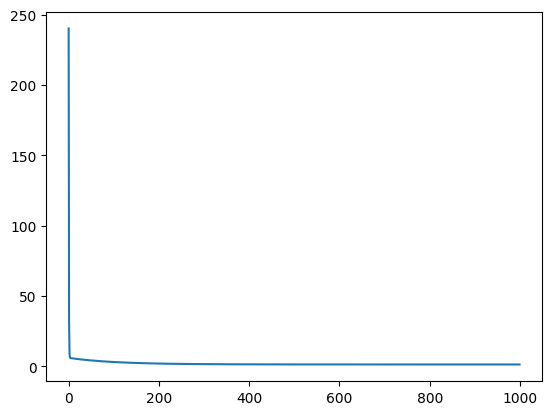

In [134]:
plt.plot(torch.arange(n_iter), losses)